
# 📘 Module 20: AdaBoost (Adaptive Boosting) – Practice Notebook

This is a **full practice notebook with detailed guidance and TODO blocks**.


## 0. Notebook Setup

We start by importing all required libraries.  


In [37]:
# TODO: Import all required libraries (Done for you)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


## 1. Understanding the Dataset

You can begin with a **synthetic binary classification dataset**. or with any exisiting dataset.

Focus questions:
- Are the classes easily separable?
- Will a weak learner struggle?


In [38]:
# TODO: Generate a binary classification dataset
# Hint:
# - n_samples around 500
# - n_features = 2
# - class_sep > 1
X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=1.5,
    random_state=42
)

# Convert to DataFrame (optional but good for analysis)
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])
df['Target'] = y

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (500, 3)


,Feature_1,Feature_2,Target
0,1.508455,-1.547010,0
1,0.826021,1.002541,1
2,1.524205,-2.297143,0
3,0.621880,0.559371,0
4,0.539100,0.882369,1


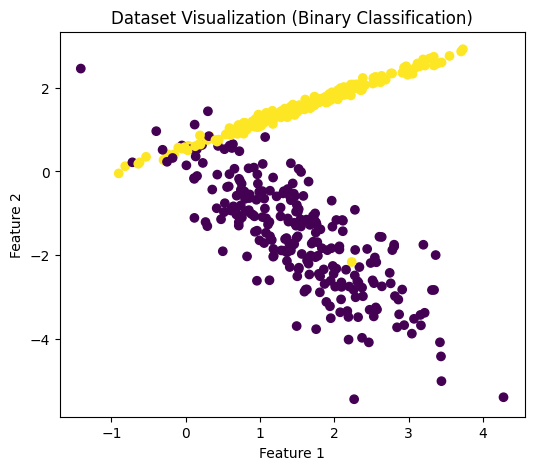

In [39]:
# TODO: Visualize the dataset using a scatter plot
# Color points by class label

# plt.scatter(...)
# plt.show()

# Visualize the dataset
plt.figure(figsize=(6,5))
plt.scatter(X[:, 0], X[:, 1], c=y, label = True)
plt.title("Dataset Visualization (Binary Classification)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


## 2. Train–Test Split

Before any model training, we split the data.

Why?
- To evaluate generalization
- To avoid lying to ourselves

Standard split:
- 70% training
- 30% testing


In [40]:
# TODO: Split the dataset into training and testing sets
# Use test_size=0.3 and random_state=42
X_train , X_test , y_train , y_test = train_test_split(X,y, test_size= 0.3, random_state= 42)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 350
Testing samples: 150



## 3. Baseline Weak Learner (Decision Stump)

Before AdaBoost, we test **one weak learner alone**.

We intentionally restrict the model:
- max_depth = 1
- This is called a **decision stump**

Expectation:
- Accuracy will not be impressive
- That is the point


In [41]:
# TODO: Create a DecisionTreeClassifier with max_depth=1
weak_learner = DecisionTreeClassifier(max_depth=1, random_state= 42)
# SVM, Logistic Regression
# This is our weak learner

In [42]:
# TODO: Train the weak learner
weak_learner.fit(X_train, y_train)
# TODO: Predict on test data
y_pred_weak = weak_learner.predict(X_test)
# TODO: Calculate and print accuracy
accuracy_weak = accuracy_score(y_test, y_pred_weak)
print("Accuracy of weak learner:", accuracy_weak)

Accuracy of weak learner: 0.94



## 4. AdaBoost Classifier – Core Practice

Now we combine **many weak learners** using AdaBoost.

Key idea:
- Each learner focuses more on previous mistakes
- Misclassified samples get more attention
- Correctly classified samples slowly matter less


In [43]:
adaboost = AdaBoostClassifier(
    estimator = DecisionTreeClassifier(max_depth=1, random_state= 42),
    n_estimators = 50,
    learning_rate = 1.0,
    random_state=42
)

In [44]:
# TODO: Train AdaBoost on training
adaboost.fit(X_train, y_train)
# TODO: Predict on test data
y_pred_ada = adaboost.predict(X_test)
# TODO: Evaluate accuracy
accuracy_ada = accuracy_score(y_test, y_pred_ada)
print("Accuracy of AdaBoost:", accuracy_ada)
# TODO: Print classification report
print(classification_report(y_test, y_pred_ada))
# TODO: Print confusion matrix
print(confusion_matrix(y_test, y_pred_ada))

Accuracy of AdaBoost: 0.9333333333333333
              precision    recall  f1-score   support

           0       0.91      0.96      0.94        75
           1       0.96      0.91      0.93        75

    accuracy                           0.93       150
   macro avg       0.93      0.93      0.93       150
weighted avg       0.93      0.93      0.93       150

[[72  3]
 [ 7 68]]



## 5. Weak Learner vs AdaBoost Comparison

Now we compare:
- One weak learner
- Many weak learners working together

Expectation:
- AdaBoost should outperform a single stump
- If not, something is wrong


In [45]:
# TODO: Create a comparison table
# Columns:
# - Model
# - Accuracy
cmp_t = pd.DataFrame({
        "Model": ["Weak Learner (Decision Stump)", "AdaBoost"],
        "Accuracy": [accuracy_weak, accuracy_ada]
})
cmp_t

,Model,Accuracy
0,Weak Learner (Decision Stump),0.940000
1,AdaBoost,0.933333



## 6. Effect of Number of Estimators

AdaBoost performance depends heavily on:
- Number of estimators

More is not always better.

Your job:
- Experiment
- Observe
- Plot


In [46]:
# TODO: Try different n_estimators values
# Example: [5, 10, 20, 50, 100]

# Store accuracy for each value
n_estimators_list = [5, 10, 20, 50, 100]

accuracies_estimators = []

for n in n_estimators_list:
  adaboost_model = AdaBoostClassifier(
      estimator = DecisionTreeClassifier(max_depth=1, random_state= 42),
      n_estimators = n,
      learning_rate = 1.0,
      random_state=42
      )
  adaboost_model.fit(X_train, y_train)
  y_pred = adaboost_model.predict(X_test)
  acc = accuracy_score(y_test, y_pred)
  accuracies_estimators.append(acc)

print("Accuracies for different n_estimators:", accuracies_estimators)

Accuracies for different n_estimators: [0.8866666666666667, 0.8866666666666667, 0.8866666666666667, 0.9333333333333333, 0.9333333333333333]


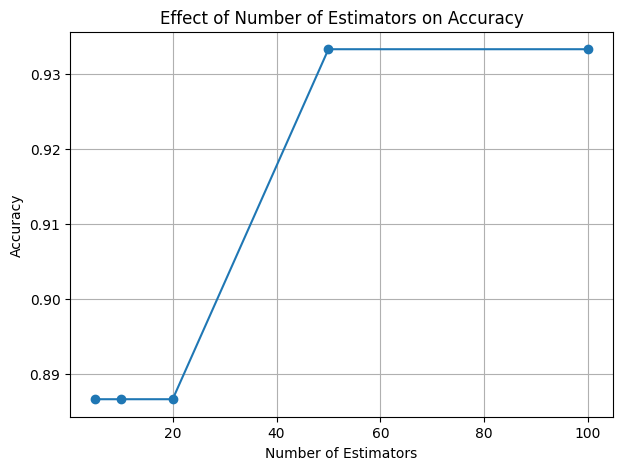

In [47]:
# TODO: Plot n_estimators vs accuracy
# Label axes clearly
plt.figure(figsize=(7,5))
plt.plot(n_estimators_list, accuracies_estimators, marker='o')
plt.title("Effect of Number of Estimators on Accuracy")
plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()


## 7. Effect of Learning Rate

Learning rate controls **how aggressively** AdaBoost updates sample weights.

Intuition:
- High learning rate → fast but risky
- Low learning rate → slow but stable

You will verify this experimentally.


In [48]:
# TODO: Experiment with different learning_rate values
# Example: [0.01, 0.1, 0.5, 1.0]
learning_rates = [0.01, 0.1, 0.5, 1.0]
accuracies_lr = []

for lr in learning_rates:
  adaboost_model = AdaBoostClassifier(
      estimator = DecisionTreeClassifier(max_depth=1, random_state= 42),
      n_estimators = 50,
      learning_rate = lr,
      random_state=42
      )
  adaboost_model.fit(X_train, y_train)
  y_pred = adaboost_model.predict(X_test)
  acc_lr = accuracy_score(y_test, y_pred)
  accuracies_lr.append(acc_lr)


print("Accuracy for learning rate", lr, ":", accuracies_lr)

Accuracy for learning rate 1.0 : [0.94, 0.94, 0.9066666666666666, 0.9333333333333333]


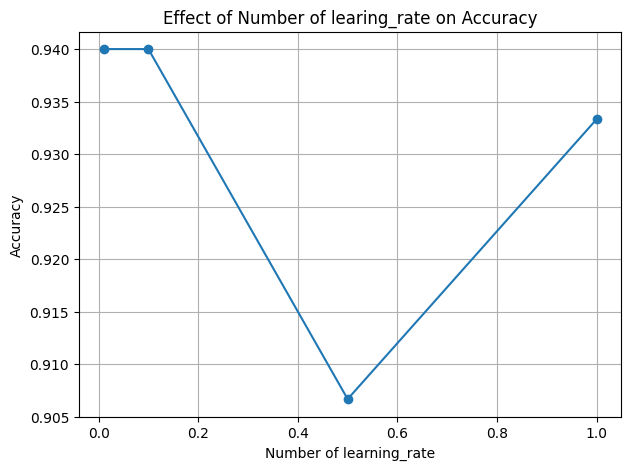

In [49]:
# TODO: Plot learning_rate vs accuracy
plt.figure(figsize=(7,5))
plt.plot(learning_rates, accuracies_lr, marker='o')
plt.title("Effect of Number of learing_rate on Accuracy")
plt.xlabel("Number of learning_rate")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()


## 8. Feature Importance in AdaBoost

AdaBoost can tell us:
- Which features were more influential

This depends on:
- How often a feature is used in splits
- How strong the corresponding learners were


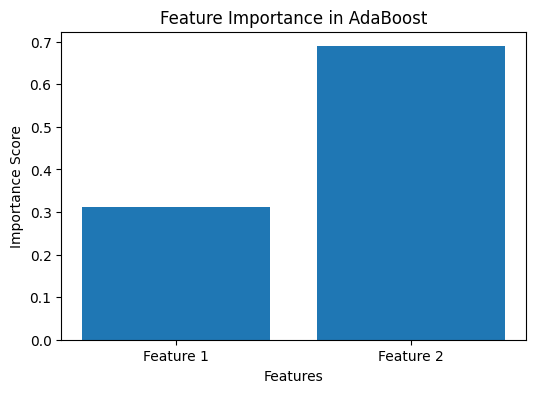

Feature Importances: [0.31102497 0.68897503]


In [50]:
# TODO: Extract feature importance from AdaBoost
# TODO: Plot feature importance
# Extract feature importance
feature_importance = adaboost.feature_importances_

# Plot feature importance
plt.figure(figsize=(6,4))
plt.bar(['Feature 1', 'Feature 2'], feature_importance)
plt.title("Feature Importance in AdaBoost")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.show()

print("Feature Importances:", feature_importance)


## 9. Reflection (Mandatory)

Answer in your own words.

1. Why is AdaBoost called *adaptive*?
2. What happens to misclassified samples after each iteration?
3. Why do we prefer weak learners instead of strong ones?
4. When should AdaBoost not be used?



## 10. Bonus Challenge (Optional)

Replace the decision stump with **Logistic Regression** as the base estimator.

Questions:
- Does AdaBoost still work?
- Should you do this in practice?
- Why or why not?


# Why is AdaBoost called adaptive?

AdaBoost is called adaptive because it adjusts the weights of training samples after each iteration, giving more importance to misclassified samples.

# What happens to misclassified samples after each iteration?

Misclassified samples receive higher weights so that the next weak learner focuses more on correcting those errors.

# Why do we prefer weak learners instead of strong ones?
Weak learners are simple and less prone to overfitting. AdaBoost combines many weak learners to build a strong and more generalizable model.

# When should AdaBoost not be used?
AdaBoost should not be used with very noisy datasets or when there are many outliers, because it gives too much importance to misclassified noisy samples.

In [52]:
# TODO: Replace DecisionTreeClassifier with LogisticRegression or SVM
# Train AdaBoost again
# Compare performance

from sklearn.linear_model import LogisticRegression

# AdaBoost with Logistic Regression
lr_base = LogisticRegression(max_iter=1000)

ada_lr = AdaBoostClassifier(
    estimator=lr_base,
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

ada_lr.fit(X_train, y_train)
y_pred_lr = ada_lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("AdaBoost with Logistic Regression Accuracy:", lr_accuracy)

AdaBoost with Logistic Regression Accuracy: 0.9133333333333333
